# Short straddles: when the loss you minimize is not the metric you are judged on

The position in this case study is a short at-the-money straddle with about a month to expiry:
sell the call and the put, collect both premiums, and keep what is left when the options expire.
It is the canonical short-volatility trade, and its payoff is asymmetric in a way that matters
for everything below. **The most it can earn is the premium it collected, so the return has a
hard ceiling. What it can lose has no bound at all, because the underlying can move as far as it
likes.** In this sample the position finishes ahead more often than not, with a typical winning
outcome a fraction of the premium and the worst outcomes many multiples of it.

That shape sets up the pedagogical question this notebook exists to answer. A linear regression
fits by **minimizing squared error**: it chooses coefficients that make its predicted return as
close as possible to the realized one, and an observation twice as far away counts four times as
much. The metric this notebook reports is the **information coefficient**, a rank correlation:
it asks only whether the positions were put in the right order, and treats a loss of twenty
percent and a loss of nine thousand percent as adjacent. On a symmetric, well-behaved target
those two agree closely enough that the distinction is academic. On this one they do not, and
section 5 reads the results in that light.

The features describe the position and the volatility surface it is written on: the greeks, the
implied volatility and its momentum, realized volatility at five horizons, the variance risk
premium at five more, the bid-ask spread, and how far the strike sits from spot. Many of them
are near-duplicates of one another, so the penalty sweep has the same job here as in every other
case study. **Regularization** adds a penalty on coefficient size to the fitting objective, and
how much to apply is an empirical question this notebook answers by trying ten orders of
magnitude of it.

Two folds, validating on 2019 and 2020. The second is a year in which a short-volatility
position experienced the event it exists to be paid for.

**Learning objectives.** By the end of this notebook you will be able to:

- Read the set of models a case study has declared for a label, and say which estimator and
  which hyperparameters each declared name resolves to.
- Bind those declarations to the data on disk and check, before anything is fitted, that every
  configuration will be measured on the same positions, the same dates and the same folds.
- Fit a population of models on walk-forward folds and publish one complete set of validation
  predictions per configuration.
- Describe the payoff of a short option position and say why squared-error loss and a rank
  correlation can disagree about the same model.
- Recognise when a modelling result is telling you about the target rather than about the
  features.
- Run configurations of your own into a private copy of the run log, and have them compared on
  the same footing as the ones shipped here.

**Book reference**: Chapter 11 (The ML Pipeline). Chapter 6, Section 6.7 (Search accounting and
run logging) introduces the run log this notebook writes to.

**Prerequisites**: [`02_labels`](02_labels.ipynb) has constructed the straddle returns,
[`03_financial_features`](03_financial_features.ipynb) and
[`04_model_based_features`](04_model_based_features.ipynb) have written the feature matrices,
and [`05_evaluation`](05_evaluation.ipynb) has established the walk-forward folds.

**What it writes**: one training run and one complete validation prediction set per
configuration, in `run_log/registry.db` and under `run_log/training/` and
`run_log/predictions/`, grouped under a named population.
[`12_backtest`](12_backtest.ipynb) reads that population, runs every member against the
equal-weight baseline, and selects on validation backtest Sharpe. **Selection happens there,
not here.** This notebook ranks configurations by information coefficient to show what
regularization does to this feature set; that ranking decides nothing.

In [1]:
"""Fit the declared short-straddle linear-model population on the walk-forward folds."""

import re

import numpy as np
import plotly.graph_objects as go
import polars as pl

from case_studies.research import (
    declared_labels,
    load_model_configs,
    model_requests,
    narrows_declared_catalog,
    open_study,
    primary_label,
    resolved_model_plan,
    run_model_population,
)
from utils.style import COLORS, show_plotly_with_alt

In [2]:
LABELS: list[str] = []
EXECUTION_TIER = "canonical"
WORKSPACE: str = ""
PREVIEW_REDUCTIONS: dict = {}
CONFIG_NAMES: list[str] = []
POPULATION_NAME = ""

In [3]:
study = open_study("sp500_options", execution_tier=EXECUTION_TIER, workspace=WORKSPACE or None)

## 1. Which label, and which models

A label is the thing being predicted. This case study puts one label in its sweep:
`ret_to_expiry`, the return the short straddle earns from the decision date to the option's
expiry. Unlike the equity case studies there is no choice of horizon here, because the horizon
is a property of the instrument rather than of the experiment - the position runs until the
contracts expire, which in this universe is between three and five weeks out.

**This notebook fits every label the sweep declares**, which here is that one. The set comes
from `labels.primary` and `labels.variants` in `config/setup.yaml`, and `variants` is empty.
`LABELS` above restricts the run to a subset when you want one.

**`config/training/` holds five menus, and four of them are not in the sweep.** `fwd_ret_5d`,
`fwd_ret_10d`, `fwd_ret_dh_5d` and `fwd_ret_dh_10d` are fixed-horizon labels that
[`02_labels`](02_labels.ipynb) still writes, because
[`03_financial_features`](03_financial_features.ipynb),
[`05_evaluation`](05_evaluation.ipynb) and [`90_ic_diagnostic`](90_ic_diagnostic.ipynb) read
them, and their menus were left in place when they were dropped from the sweep. What a menu
says is what to fit *for* a label; what `setup.yaml` says is which labels the sweep fits. The
cell below is the second of those, and it prints a one-element tuple.

In [4]:
declared_labels(study, "linear")

('ret_to_expiry',)

Each name in the menu resolves to a preset file in the shared directory
`case_studies/config/{model_type}/`, which holds that configuration's hyperparameters. The
frame below is the menu for every label above, with each name resolved to the estimator class
it names and the arguments that class is constructed with. To change what runs, edit the menu or the
presets rather than this notebook.

The grid covers the two shapes a penalty can take:

- **Ridge** penalizes the sum of squared coefficients. It shrinks correlated coefficients
  towards each other and keeps every feature, at a strength set by `alpha`. The grid steps
  `alpha` by powers of ten across ten orders of magnitude, because the useful value depends on
  the scale and the collinearity of the design matrix and neither is known in advance.
- **Lasso** penalizes the sum of absolute coefficients, which drives some of them exactly to
  zero: it selects features rather than shrinking them. **ElasticNet** mixes the two.

Lasso and ElasticNet are parameterized here by `alpha_frac` rather than a raw penalty. For any
fold there is a threshold penalty $\alpha_{\max}$ - the smallest one that zeros every
coefficient - which is computed from that fold's own data. `alpha_frac` is the fraction of it
to apply, so one declared `alpha_frac` means the same thing on every fold, while a fixed raw
penalty would mean something different on each.

In [5]:
configs = load_model_configs(
    study,
    "linear",
    labels=LABELS or None,
    config_names=CONFIG_NAMES or None,
)
configs

family,label,config_name,model_class,params
str,str,str,str,str
"""linear""","""ret_to_expiry""","""ridge_a1000.0""","""Ridge""","""alpha=1000.0"""
"""linear""","""ret_to_expiry""","""ridge_a10000.0""","""Ridge""","""alpha=10000.0"""
"""linear""","""ret_to_expiry""","""ridge_a100.0""","""Ridge""","""alpha=100.0"""
"""linear""","""ret_to_expiry""","""ridge_a1.0""","""Ridge""","""alpha=1.0"""
"""linear""","""ret_to_expiry""","""ridge_a10.0""","""Ridge""","""alpha=10.0"""
…,…,…,…,…
"""linear""","""ret_to_expiry""","""enet_f0.03""","""ElasticNet""","""alpha_frac=0.03, l1_ratio=0.5,…"
"""linear""","""ret_to_expiry""","""enet_f0.015""","""ElasticNet""","""alpha_frac=0.015, l1_ratio=0.5…"
"""linear""","""ret_to_expiry""","""enet_f0.35""","""ElasticNet""","""alpha_frac=0.35, l1_ratio=0.5,…"


`LABELS` and `CONFIG_NAMES` both narrow what is fitted, and a narrowed run declares a different
set of members than the canonical population does. A population is immutable once written, so
such a run must publish under its own name. Comparing the loaded rows against the complete
declared catalog catches either knob, and says so here rather than several cells later in a
message about hashes.

In [6]:
if narrows_declared_catalog(study, "linear", configs) and not POPULATION_NAME:
    raise ValueError(
        f"this run declares {configs.height} label-configuration pairs, which is not the "
        f"complete declared catalog, so it cannot publish the canonical population; pass "
        f"POPULATION_NAME to give it its own"
    )

## 2. Binding the declarations to the data

A menu entry says which estimator to fit. It does not say which feature columns exist today,
where the walk-forward folds fall, or which position-date pairs have both a feature row and a
label. **Resolving** a request is the step that goes and finds all of that: it reads the label
and feature files, computes the fold boundaries from the walk-forward parameters in
`config/setup.yaml`, works out the exact set of rows each fit is expected to predict, and turns
any data-dependent hyperparameter into the number it will actually use - each fold's own
$\alpha_{\max}$ times `alpha_frac`, in the case of Lasso.

Resolving reads the inputs and fits nothing, so the plan below can be inspected before any
computation starts. The three things to check in it:

- **`feature_count`, `eligible_entities` and `eligible_rows` agree across every row.** They are
  the width of the design matrix, the number of underlyings with a tradable straddle, and the
  number of position-date pairs to be predicted. Every configuration here reads the same feature
  matrix, so a row that differs is a configuration being measured on a different sample from its
  neighbours, and its results are not comparable with theirs.
- **`folds` is the same everywhere**, and equals the number of walk-forward splits
  `05_evaluation` established.
- **`validation_start` and `validation_end` bracket the development sample.** The held-out tail
  must not appear here: it is scored once, at the end of the case study, and any of it visible
  in this window would mean it had been used to choose something.

Each row also carries a `training_hash`: the identity of that computation, derived from
everything that can change its result. [`RUN_LOG.md`](../RUN_LOG.md#identity) sets out what goes
into one and what follows from it.

In [7]:
requests = model_requests(
    study,
    configs,
    execution_tier=EXECUTION_TIER,
    preview_reductions=PREVIEW_REDUCTIONS,
)
resolved = tuple(request.resolve() for request in requests)

plan = resolved_model_plan(resolved)
plan.select(
    "config_name",
    "feature_count",
    "eligible_entities",
    "eligible_rows",
    "folds",
    "validation_start",
    "validation_end",
)

config_name,feature_count,eligible_entities,eligible_rows,folds,validation_start,validation_end
str,i64,i64,i64,i64,date,date
"""enet_f0.015""",52,539,132210,2,2019-01-07,2020-11-10
"""enet_f0.03""",52,539,132210,2,2019-01-07,2020-11-10
"""enet_f0.08""",52,539,132210,2,2019-01-07,2020-11-10
"""enet_f0.2""",52,539,132210,2,2019-01-07,2020-11-10
"""enet_f0.35""",52,539,132210,2,2019-01-07,2020-11-10
…,…,…,…,…,…,…
"""ridge_a1000.0""",52,539,132210,2,2019-01-07,2020-11-10
"""ridge_a10000.0""",52,539,132210,2,2019-01-07,2020-11-10
"""ridge_a100000.0""",52,539,132210,2,2019-01-07,2020-11-10


## 3. Fitting the population

`run_model_population` fits every resolved request. For one request it walks the folds, and on
each one:

1. takes the rows inside that fold's training window,
2. fills missing feature values with the training window's median for that column, then
   standardizes each column to zero mean and unit variance - both fitted on training rows only
   and then applied to the validation rows, so nothing from the validation window reaches the
   fit,
3. fits the estimator with that fold's resolved parameters,
4. predicts the fold's validation rows.

The fold predictions are concatenated into one series covering the whole validation period,
which is what a walk-forward prediction set is: each date predicted by a model that saw only
data before it. The run then writes a `training_runs` row and the fitted coefficients, a
`prediction_sets` row and the predictions themselves, and the metrics computed from them. It
does this per configuration rather than once at the end, so an interruption costs the
configuration in flight and nothing else.

Every case study that fits linear models calls this same runner, which is what makes their
results comparable. Unlike gradient boosting or a neural network, a linear model has no
intermediate states worth scoring: there is one fit and therefore one checkpoint per
configuration, and no learning curve to plot.

**What the call publishes is a population**: a named, immutable list of the prediction sets it
is going to produce. The list is computed from the resolved specifications before the first fit
and written down, and afterwards every member must exist and be complete. That is what makes
the downstream comparison well defined - `12_backtest` backtests this population, not whatever
predictions happen to be in the registry - and it is why a configuration that raises fails the
whole call rather than publishing a population one member short. Everything that finished stays
registered, and re-running fits only what is missing.

In [8]:
# `11_model_analysis` and `12_backtest` resolve this population by name, so the default is
# the contract with them and not a label of convenience. A run that narrows the member set
# has to pass its own.
population_name = POPULATION_NAME or "sp500-options-linear-validation-v1"
execution, population = run_model_population(study, resolved, population_name=population_name)

fitted = sum(len(item["fitted_folds"]) for item in execution.diagnostics)
reused = sum(len(item["reused_folds"]) for item in execution.diagnostics)
print(f"{len(execution.runs)} configurations: {fitted} folds fitted, {reused} reused")
print(f"population {population.name}: {len(population.members)} prediction sets")

28 configurations: 0 folds fitted, 56 reused
population sp500-options-linear-validation-v1: 28 prediction sets


`reused` is not zero on a second run. Every identity is re-derived from the inputs, the
registry already holds the matching rows, and the runner returns the stored result rather than
fitting again - so re-running this notebook unchanged costs the time it takes to read the data.

### Running configurations of your own

The published run log is read-only. To add runs, open the study against a workspace, which
holds its own registry and artifacts and reads the same labels and features:

```python
study = open_study("sp500_options", workspace="~/ml4t-experiments")
configs = load_model_configs(
    study, "linear", labels=["ret_to_expiry"], config_names=["ols", "ridge_a1.0", "ridge_a3.0"]
)
requests = model_requests(study, configs)
resolved = tuple(request.resolve() for request in requests)
execution, population = run_model_population(study, resolved, population_name="my-linear-v1")
```

`CONFIG_NAMES` fits a subset of what the menu already declares; a name the menu does not
declare raises rather than quietly fitting fewer models than you asked for. To fit something
new, add a preset at `case_studies/config/ridge/ridge_a3.0.yaml` and list `ridge_a3.0` under
`linear:` in the label's menu. Editing an existing preset changes that configuration's
identity, so its result registers as a new row beside the old one instead of replacing it.

Give the run its own `population_name`: a name refers to one set of members permanently, and
reusing it for a different set raises. Everything downstream reads the registry rather than the
notebook, so predictions produced this way are selected and backtested on the same footing as
the ones shipped here, inside your workspace.
[`RUN_LOG.md`](../RUN_LOG.md#running-your-own-configurations) covers the rest, including how to
rehearse on a reduced universe first.

## 4. What the target looks like

Before the model results, the target itself, because the shape of this distribution is what the
results below turn on. Each observation is one straddle held to expiry. The counts are drawn on
a logarithmic axis, because the left tail is thousands of times rarer than the mode and a
linear count axis would flatten it to nothing.

**Measured on the development sample only.** The label artifact on disk runs to the end of the
data, holdout included, and `02_labels` says so: the files carry the sealed sessions and no
diagnostic reads them. Describing the target across all of it would put a statistic computed
partly on sealed outcomes into a validation-stage notebook, so the rows are cut at the
development boundary the fits above were resolved against, taken from the plan rather than
re-derived from `setup.yaml`.

Two features of it matter. There is a hard ceiling: the most a short straddle can earn is the
premium it collected, so nothing exceeds a return of one. There is no floor: a large enough move
in the underlying costs a multiple of the premium, and the worst observations in this sample are
many multiples. The result is a distribution whose typical outcome is a modest gain and whose
mean is dragged below zero by a small number of very large losses.

In [9]:
# The label the strategy trades, read from `setup.yaml` rather than from a constant here, so
# this section describes the same target the sweep publishes against.
primary = primary_label(study)
development_end = plan.get_column("validation_end").max()
label_values = (
    study.labels.get(primary, execution_tier=EXECUTION_TIER)
    .load()
    .filter(pl.col("timestamp") <= development_end)
    .get_column(primary)
    .drop_nulls()
    .to_numpy()
)
print(f"{len(label_values):,} straddles resolved on or before {development_end}")

summary = pl.DataFrame(
    {
        "statistic": ["minimum", "median", "mean", "maximum", "share positive", "share below -1"],
        "value": [
            float(label_values.min()),
            float(np.median(label_values)),
            float(label_values.mean()),
            float(label_values.max()),
            float((label_values > 0).mean()),
            float((label_values < -1).mean()),
        ],
    }
)
summary

277,296 straddles resolved on or before 2020-11-10


statistic,value
str,f64
"""minimum""",-81.692308
"""median""",0.16684
"""mean""",-0.053727
"""maximum""",1.0
"""share positive""",0.581931
"""share below -1""",0.116157


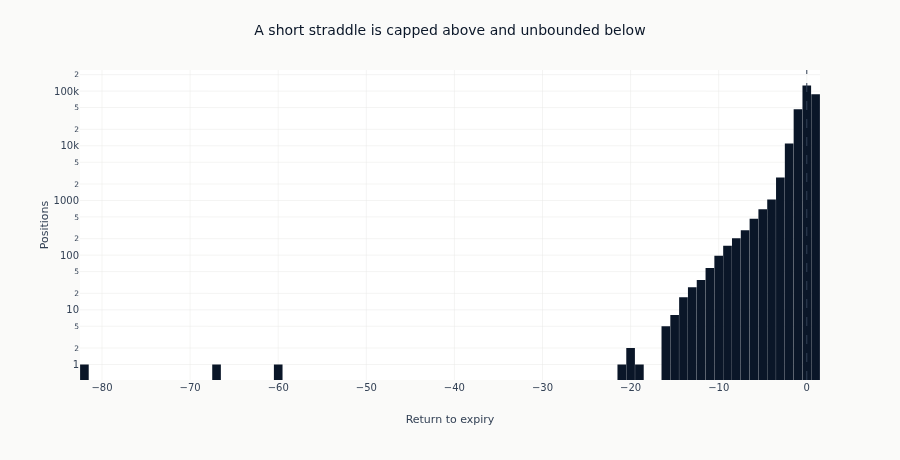

In [10]:
fig_label = go.Figure(
    go.Histogram(
        x=label_values,
        nbinsx=120,
        marker_color=COLORS["blue"],
    )
)
fig_label.add_vline(x=0, line_width=1, line_dash="dash", line_color=COLORS["neutral"])
fig_label.update_layout(
    title="A short straddle is capped above and unbounded below",
    height=460,
    width=900,
    showlegend=False,
    margin=dict(t=70),
    bargap=0.02,
)
fig_label.update_xaxes(title_text="Return to expiry", type="linear")
fig_label.update_yaxes(title_text="Positions", type="log")
show_plotly_with_alt(
    fig_label,
    "Histogram of the short straddle's return to expiry on a logarithmic count axis. The mass "
    "sits between a small loss and a return of one, with a hard edge at one and a long thin tail "
    "of losses extending far to the left of a dashed line at zero.",
)

## 5. What the models produced

One row per configuration, read back from the registry. `ic_mean` is the **information
coefficient**: on each validation date, rank the positions by the model's prediction, rank them
by the return they went on to earn, correlate the two rankings, and average that correlation
over the validation period. It measures whether the model ranks positions correctly, on a scale
where zero is no relationship, positive means the ranking points the right way, and negative
means it points the wrong way.

`ic_n_days` is how many validation dates produced a defined correlation. A model whose
coefficients collapse to one or two features predicts nearly the same value for every position
on some dates, and a constant has no rank correlation with anything, so those dates would
contribute nothing. `full_coverage` marks the configurations measured on all of them.

In [11]:
catalog = (
    execution.catalog_rows.select(
        "config_name",
        "label",
        "complete",
        "ic_mean",
        "ic_std",
        "ic_n_days",
        "n_folds",
        "training_hash",
        "prediction_hash",
    )
    .sort(["label", "ic_mean"], descending=[False, True])
    .join(
        configs.select("config_name", "label", "model_class", "params"),
        on=["config_name", "label"],
        how="left",
    )
)

if catalog.filter(~pl.col("complete")).height:
    raise RuntimeError("linear execution returned a partial prediction set")

# Coverage is judged against each label's own maximum. The sweep declares one label today, so
# this is the same number either way; it is written per label because adding a variant to
# `setup.yaml` is all it takes for a global maximum to mark a whole grid incomplete for a reason
# that has nothing to do with the models.
catalog = catalog.with_columns(
    full_coverage=pl.col("ic_n_days") == pl.col("ic_n_days").max().over("label")
)
# The charts below are one panel, which is only right while the sweep is one label. A variant
# added to `setup.yaml` has to be faceted the way `fx_pairs` and `cme_futures` facet theirs,
# rather than silently pooled into one ranking.
if catalog.get_column("label").n_unique() > 1:
    raise NotImplementedError(
        "this notebook charts one label; facet the figures before adding a sweep variant"
    )
catalog.select(
    "config_name",
    "model_class",
    "params",
    "ic_mean",
    "ic_std",
    "ic_n_days",
    "full_coverage",
)

config_name,model_class,params,ic_mean,ic_std,ic_n_days,full_coverage
str,str,str,f64,f64,f64,bool
"""ridge_a10000000.0""","""Ridge""","""alpha=10000000.0""",-0.002259,0.009572,467.0,true
"""ridge_a1000000.0""","""Ridge""","""alpha=1000000.0""",-0.003725,0.011035,467.0,true
"""lasso_f0.7""","""Lasso""","""alpha_frac=0.7, max_iter=5000""",-0.006353,0.00863,467.0,true
"""enet_f0.7""","""ElasticNet""","""alpha_frac=0.7, l1_ratio=0.5, …",-0.006393,0.008727,467.0,true
"""lasso_f0.85""","""Lasso""","""alpha_frac=0.85, max_iter=5000""",-0.008818,0.006083,467.0,true
…,…,…,…,…,…,…
"""enet_f0.08""","""ElasticNet""","""alpha_frac=0.08, l1_ratio=0.5,…",-0.011047,0.002287,467.0,true
"""enet_f0.2""","""ElasticNet""","""alpha_frac=0.2, l1_ratio=0.5, …",-0.011436,0.004223,467.0,true
"""lasso_f0.2""","""Lasso""","""alpha_frac=0.2, max_iter=5000""",-0.011454,0.004102,467.0,true


### How the penalty grid ranks

Only the configurations measured on all `full_days` validation dates are charted. The zero line
is the reference that matters: a bar below it is a model whose ranking pointed the wrong way out
of sample.

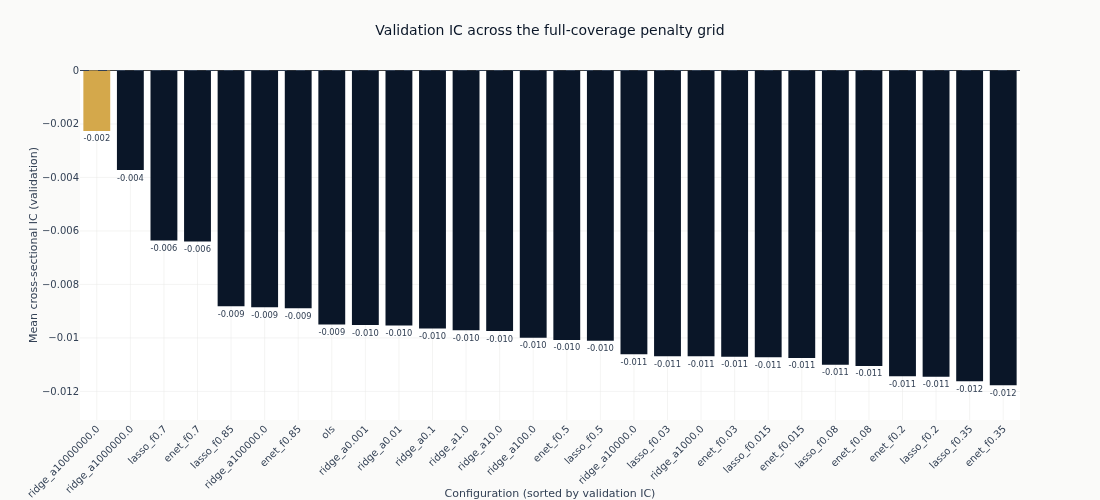

In [12]:
def compact(params: str) -> str:
    """Render declared parameters for a label: `alpha=1000000.0` reads as `alpha=1e+06`."""
    return re.sub(r"\d+\.?\d*(?:[eE][+-]?\d+)?", lambda m: f"{float(m.group()):g}", params)


full = catalog.filter("full_coverage")
leader = full.row(0, named=True)

fig_ic = go.Figure(
    go.Bar(
        x=full.get_column("config_name").to_list(),
        y=full.get_column("ic_mean").to_list(),
        marker_color=[
            COLORS["amber"] if name == leader["config_name"] else COLORS["blue"]
            for name in full.get_column("config_name")
        ],
        text=[f"{value:+.3f}" for value in full.get_column("ic_mean")],
        textposition="outside",
        cliponaxis=False,
    )
)
fig_ic.add_hline(y=0, line_width=1, line_dash="dash", line_color=COLORS["neutral"])
fig_ic.update_layout(
    title="Validation IC across the full-coverage penalty grid",
    height=500,
    width=1100,
    showlegend=False,
    margin=dict(t=70),
)
fig_ic.update_xaxes(title_text="Configuration (sorted by validation IC)", tickangle=-45)
fig_ic.update_yaxes(title_text="Mean cross-sectional IC (validation)")
show_plotly_with_alt(
    fig_ic,
    "Bar chart of mean validation information coefficient for every full-coverage linear "
    f"configuration, sorted descending, against a dashed zero line. {leader['config_name']} "
    f"({compact(leader['params'])}) is highlighted in amber at the top of the ranking at IC "
    f"{leader['ic_mean']:+.3f}. Every bar falls below the zero line.",
)

### What shrinkage does on its own

The bar chart mixes three estimators. Tracing IC across the Ridge penalty alone isolates the
effect of shrinkage, with the estimator, the features and the folds all held fixed and only
`alpha` moving. The alpha is read from each configuration's declared parameters rather than
parsed out of its name, so the curve plots what was fitted.

In [13]:
ridge = (
    catalog.filter(pl.col("model_class") == "Ridge")
    .with_columns(
        alpha=pl.col("params").str.extract(r"alpha=([0-9.eE+-]+)").cast(pl.Float64),
    )
    .drop_nulls("alpha")
    .sort("alpha")
)
if ridge.height:
    log_alpha = np.log10(ridge.get_column("alpha").to_numpy())
    ridge_ic = ridge.get_column("ic_mean").to_numpy()
    peak = int(np.argmax(ridge_ic))
else:
    print(
        "No declared label declares Ridge configurations, so there is no penalty sweep to trace. "
        "Which estimators this section can show is decided by the menus at "
        "config/training/*.yaml."
    )

The penalty grid spans ten orders of magnitude, so it is read on a log axis.

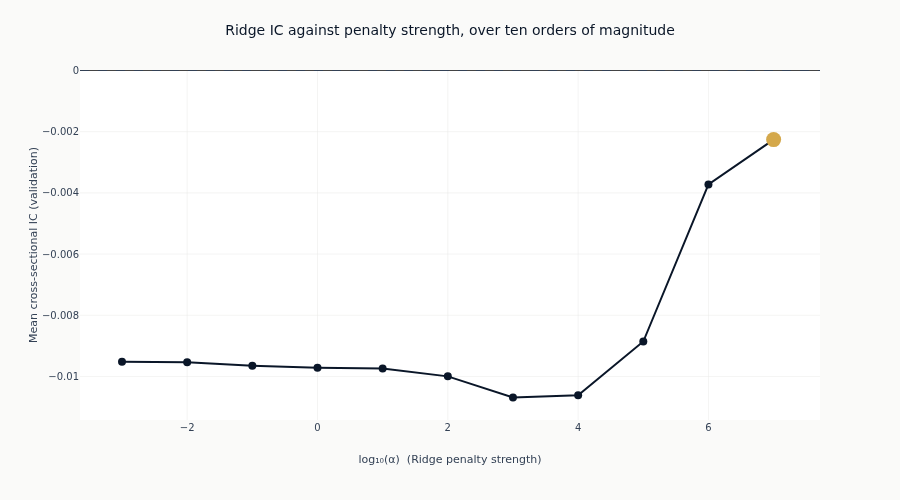

In [14]:
if ridge.height:
    fig_alpha = go.Figure(
        go.Scatter(
            x=log_alpha,
            y=ridge_ic,
            mode="lines+markers",
            line=dict(color=COLORS["blue"], width=2),
            marker=dict(size=8, color=COLORS["blue"]),
        )
    )
    fig_alpha.add_trace(
        go.Scatter(
            x=[log_alpha[peak]],
            y=[ridge_ic[peak]],
            mode="markers",
            marker=dict(size=15, color=COLORS["amber"]),
            showlegend=False,
        )
    )
    fig_alpha.add_hline(y=0, line_width=1, line_dash="dash", line_color=COLORS["neutral"])
    fig_alpha.update_layout(
        title="Ridge IC against penalty strength, over ten orders of magnitude",
        height=500,
        width=900,
        showlegend=False,
        margin=dict(t=70),
    )
    fig_alpha.update_xaxes(title_text="log₁₀(α)  (Ridge penalty strength)", zeroline=False)
    fig_alpha.update_yaxes(title_text="Mean cross-sectional IC (validation)")
    show_plotly_with_alt(
        fig_alpha,
        "Line chart of mean validation information coefficient against the base-ten logarithm of the "
        "Ridge penalty, against a dashed zero line. The curve sits below zero across the grid and "
        f"rises towards zero as the penalty strengthens, reaching its maximum at "
        f"1e{int(round(log_alpha[peak]))} marked in amber.",
    )

## 6. What to notice

**No configuration clears zero, and the strongest shrinkage comes closest to it.** The Ridge
curve rises towards zero as the penalty grows, which is the shape you get when the penalty's
only remaining job is to undo what the unpenalized fit learned. A sufficiently penalized linear
model predicts a constant, a constant has no rank correlation with anything, and zero is the
value this curve is climbing towards. When that is the direction of improvement, the fit has no
ranking to defend.

**The target explains more of this than the features do.** Return the histogram in section 4.
Least squares chooses coefficients to minimize the average squared distance between the
predicted return and the realized one, so a position that lost nine thousand percent contributes
about two hundred thousand times as much to the objective as one that lost twenty percent. The
fit is therefore almost entirely a description of the left tail: it is trying to say which
straddles blow up. The information coefficient asks a different question - were the positions in
the right order - and in that question the catastrophe and the mild loss are neighbours. Two
reasonable-looking choices, squared-error loss and rank correlation, are here measuring nearly
disjoint things, and the grid is the evidence of how far apart they can get.

**This is a property of the instrument, not a modelling mistake.** A short option position is
capped above and unbounded below because that is what selling insurance is. The target could be
transformed - winsorized, ranked, or replaced by a loss function that does not square the
residual - and each of those is a different experiment with a different meaning, not a fix to be
applied silently. What the linear stage establishes is that the untransformed target and a
squared-error fit do not combine into a ranking model, which is worth knowing before more
expressive families are pointed at the same pair.

**Two folds, and one of them is 2020.** A short-volatility position experienced in that year
precisely the event it exists to be compensated for. Half the validation evidence therefore
comes from the part of the distribution that dominates the fitting objective, and with two folds
there is no way to separate a weak feature set from an unrepresentative window.

**None of this selects anything.** IC measures whether predictions rank positions correctly, not
whether a strategy trading them makes money after costs. Those come apart further here than
anywhere else in this book: a short straddle earns its premium whether or not the ranking was
right, and the bid-ask spread on a monthly option is wide enough to decide the outcome on its
own. Selection is on validation backtest Sharpe over the population this notebook just
published, and it happens in [`12_backtest`](12_backtest.ipynb).

**Known limitations.** The IC is an average of per-date rank correlations with no adjustment for
the overlap that month-long holding periods create. The grid is a one-dimensional sweep of
penalty strength at fixed features and fixed folds. And every number here is measured on the
validation folds, which have been read many times over by the time a case study reaches this
notebook.

**Next**: [`07_gbm`](07_gbm.ipynb) fits gradient boosting to the same target. It inherits the
squared-error objective and therefore the same exposure to the left tail, so the comparison to
watch is not whether it ranks better but whether its extra flexibility goes into describing the
tail more finely - which would help the loss and not the ranking at all.